In [5]:
import pyodbc
import pandas as pd
from sqlalchemy import create_engine

In [6]:
conn = pyodbc.connect(
    'Driver={SQL Server};'
    'Server=DESKTOP-3N1QTPU\\SQLEXPRESS;'
    'Database=DA07_Movies_Db;'
    'Trusted_Connection=yes;'
)

print("Connected Successfully!")

Connected Successfully!


In [7]:
query = "SELECT * FROM Movies"

movies_df = pd.read_sql(query, conn)

movies_df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_27948\4102506859.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  movies_df = pd.read_sql(query, conn)


,movie_id,title,year,genre,language,country,total_views
0,1,Toy Story,1995,Animation|Children's|Comedy,German,Italy,69118
1,2,Jumanji,1995,Adventure|Children's|Fantasy,Spanish,UK,1661
2,3,Grumpier Old Men,1995,Comedy|Romance,English,India,22205
3,4,Waiting to Exhale,1995,Comedy|Drama,Spanish,India,84783
4,5,Father of the Bride Part II,1995,Comedy,German,India,61291


In [8]:
query = """
SELECT TOP 10
    m.title,
    ROUND(AVG(r.rating), 2) AS average_rating
FROM Ratings r
JOIN Movies m
    ON r.movie_id = m.movie_id
GROUP BY m.title
HAVING COUNT(r.rating_id) >= 5
ORDER BY average_rating DESC;
"""

top_movies = pd.read_sql(query, conn)

top_movies

C:\Users\Admin\AppData\Local\Temp\ipykernel_27948\798391754.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_movies = pd.read_sql(query, conn)


,title,average_rating
0,Remember the Titans,4.62
1,High Plains Drifter,4.26
2,Nightmare on Elm Street A,4.14
3,$1000000 Duck,4.02
4,SubUrbia,4.02
5,B. Monkey,3.96
6,Private Parts,3.96
7,The Mountain Eagle,3.95
8,Mr. Smith Goes to Washington,3.94
9,The Man Who Knew Too Much,3.92


In [6]:
print(top_movies)

                          title  average_rating
0           Remember the Titans            4.62
1           High Plains Drifter            4.26
2     Nightmare on Elm Street A            4.14
3                 $1000000 Duck            4.02
4                      SubUrbia            4.02
5                     B. Monkey            3.96
6                 Private Parts            3.96
7            The Mountain Eagle            3.95
8  Mr. Smith Goes to Washington            3.94
9     The Man Who Knew Too Much            3.92


In [3]:
import matplotlib.pyplot as plt

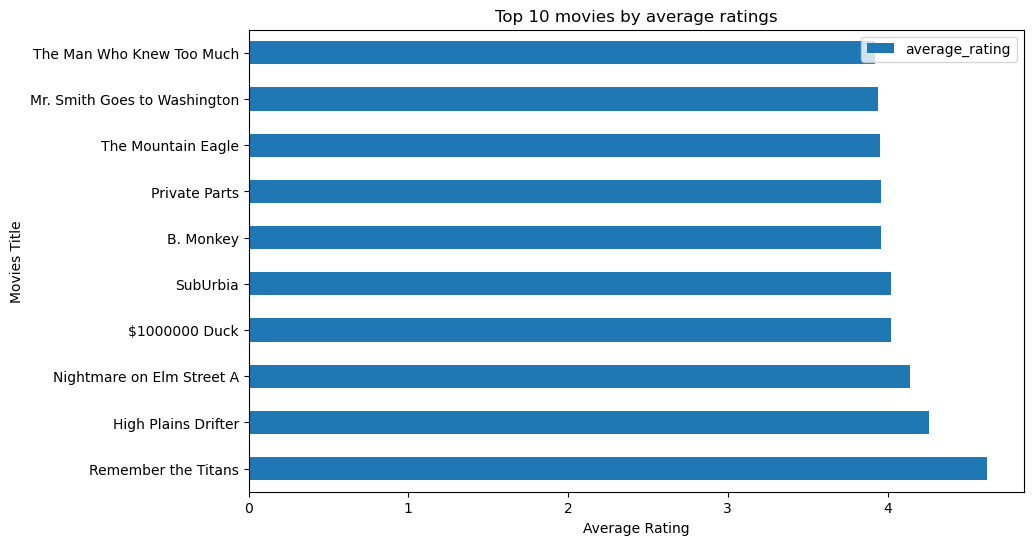

In [18]:
top_movies.plot(
    x='title', 
    y='average_rating',
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 movies by average ratings')
plt.xlabel('Average Rating')
plt.ylabel('Movies Title')
plt.show()

In [11]:
query = """
SELECT Top 10
    m.genre,
    COUNT(r.rating_id) AS total_ratings
FROM Ratings r
JOIN Movies m
    ON r.movie_id = m.movie_id
GROUP BY m.genre
ORDER BY total_ratings DESC;
"""

genres_df = pd.read_sql(query, conn)

genres_df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_27948\1355250336.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  genres_df = pd.read_sql(query, conn)


,genre,total_ratings
0,Drama,2216
1,Comedy,1312
2,Horror,454
3,Comedy|Drama,394
4,Comedy|Romance,384


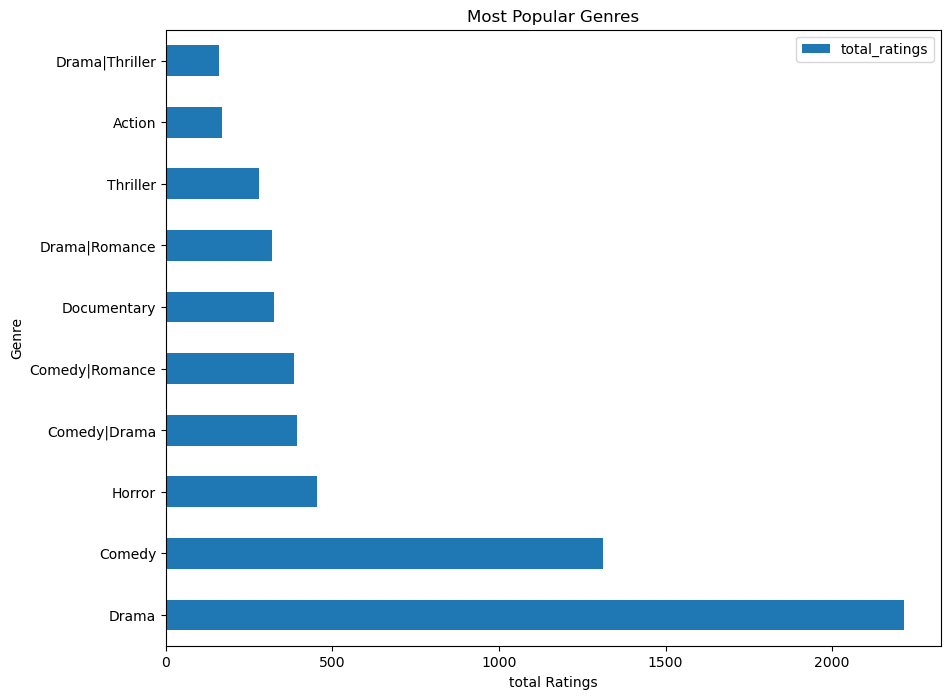

In [12]:
genres_df.plot(
    x='genre', 
    y='total_ratings',
    kind='barh',
    figsize=(10,8)
)

plt.title('Most Popular Genres')
plt.xlabel('total Ratings')
plt.ylabel('Genre')
plt.show()

In [13]:
query = """
SELECT
    CASE
        WHEN age < 18 THEN 'Under 18'
        WHEN age BETWEEN 18 AND 24 THEN '18-24'
        WHEN age BETWEEN 25 AND 34 THEN '25-34'
        WHEN age BETWEEN 35 AND 44 THEN '35-44'
        WHEN age BETWEEN 45 AND 54 THEN '45-54'
        ELSE '55+'
    END AS age_group,
    COUNT(*) AS total_users
FROM Users
GROUP BY
    CASE
        WHEN age < 18 THEN 'Under 18'
        WHEN age BETWEEN 18 AND 24 THEN '18-24'
        WHEN age BETWEEN 25 AND 34 THEN '25-34'
        WHEN age BETWEEN 35 AND 44 THEN '35-44'
        WHEN age BETWEEN 45 AND 54 THEN '45-54'
        ELSE '55+'
    END
ORDER BY age_group;
"""

age_df = pd.read_sql(query, conn)

age_df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_27948\4218664067.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  age_df = pd.read_sql(query, conn)


,age_group,total_users
0,18-24,716
1,25-34,1054
2,35-44,1104
3,45-54,1076
4,55+,1166


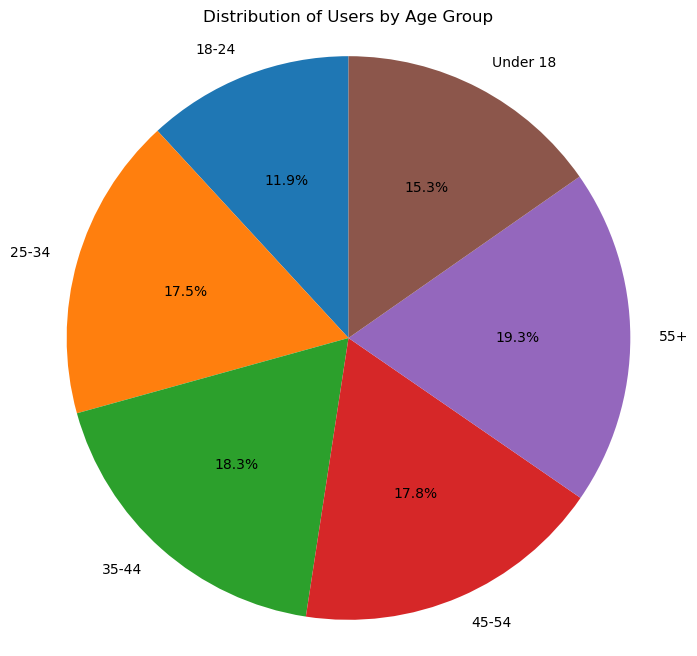

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.pie(
    age_df['total_users'],
    labels=age_df['age_group'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Users by Age Group')
plt.axis('equal')   # Makes the pie chart a circle

plt.show()

In [15]:
query = """
select subscription_status, count(user_id) AS total_users from Users
group by subscription_status
"""

subscription_df = pd.read_sql(query, conn)

subscription_df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_27948\3779877324.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  subscription_df = pd.read_sql(query, conn)


,subscription_status,total_users
0,Subscriber,2956
1,Free,3084


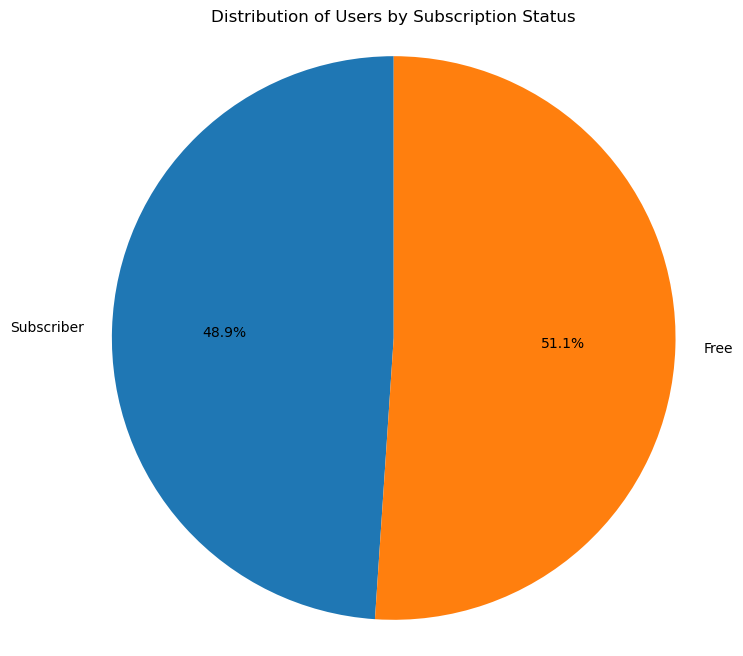

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.pie(
    subscription_df['total_users'],
    labels=subscription_df['subscription_status'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Users by Subscription Status')
plt.axis('equal')   # Makes the pie chart a circle

plt.show()

In [17]:
query = """
SELECT
    country,
    COUNT(*) AS total_users
FROM Users
GROUP BY country
ORDER BY total_users DESC;
"""

country_df = pd.read_sql(query, conn)

country_df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_27948\16258295.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  country_df = pd.read_sql(query, conn)


,country,total_users
0,Canada,1034
1,USA,1022
2,India,1021
3,Italy,1016
4,France,986


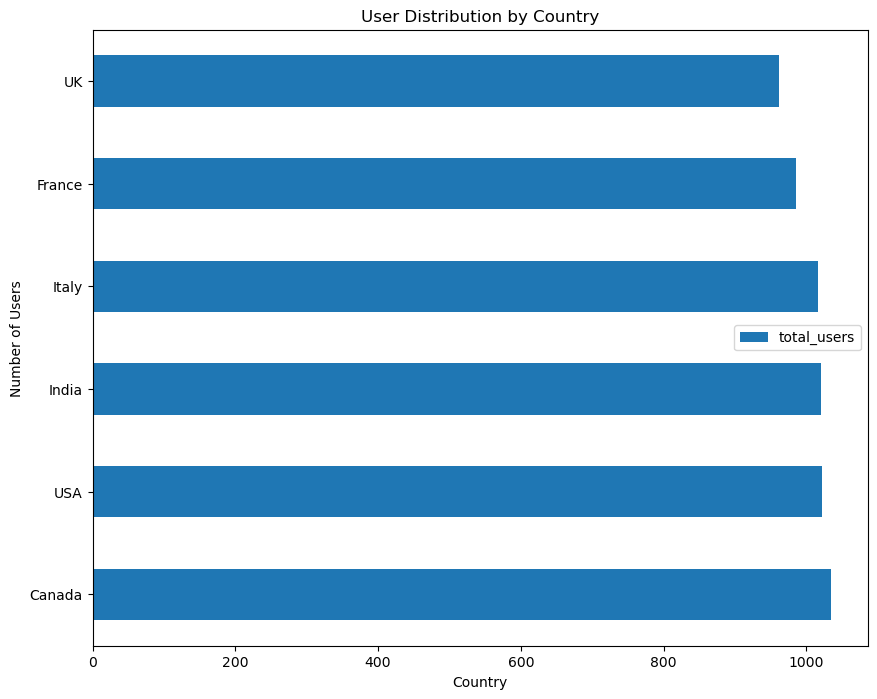

In [18]:
country_df.plot(
    x='country', 
    y='total_users',
    kind='barh',
    figsize=(10,8)
)

plt.title('User Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.show()

In [19]:
query = """
SELECT
    device,
    COUNT(*) AS total_users
FROM Users
GROUP BY device
ORDER BY total_users DESC;
"""

devices_df = pd.read_sql(query, conn)

devices_df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_27948\4141551075.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  devices_df = pd.read_sql(query, conn)


,device,total_users
0,Mobile,1549
1,Smart TV,1499
2,Desktop,1497
3,Tablet,1495


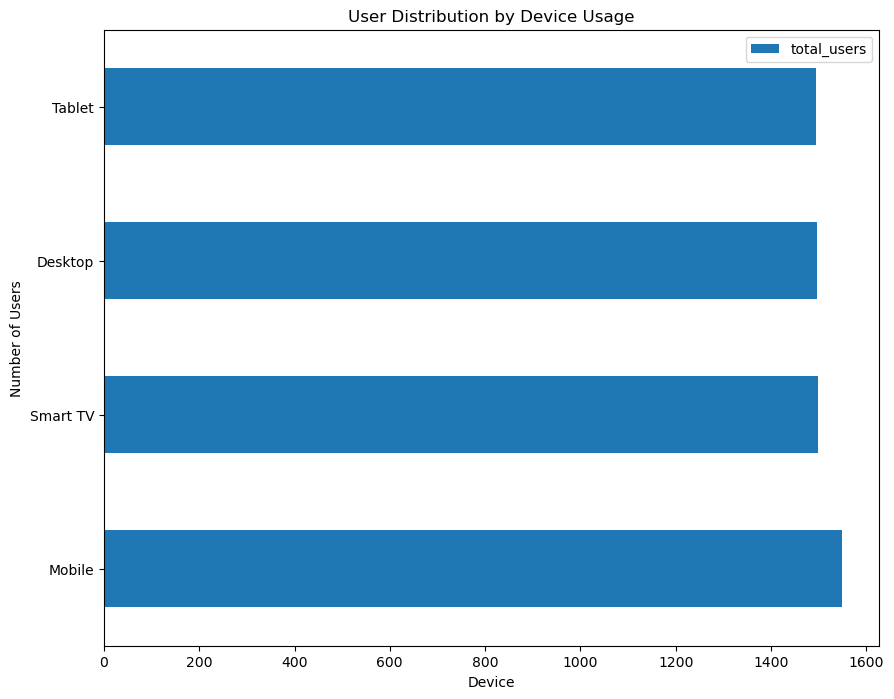

In [21]:
devices_df.plot(
    x='device', 
    y='total_users',
    kind='barh',
    figsize=(10,8)
)

plt.title('User Distribution by Device Usage')
plt.xlabel('Device')
plt.ylabel('Number of Users')
plt.show()